In [3]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the zip file
with zipfile.ZipFile('/content/archive (1).zip', 'r') as z:
    z.extractall('/content/')
    print("Files extracted:", z.namelist())

# Load the Titanic-Dataset.csv
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Files extracted: ['Titanic-Dataset.csv']

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.100

In [4]:
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum())

Shape: (891, 12)

Column Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Null Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Summary statistics for numeric columns
print("Numeric Columns Summary:")
print(df.describe())
# describe() → shows count, mean, std, min, 25%, 50%, 75%, max
# helps understand center and spread of each numeric column

# Summary statistics for categorical/text columns
print("\nCategorical Columns Summary:")
print(df.describe(include='object'))
# include='object' → shows count, unique, top, freq for text columns

Numeric Columns Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Categorical Columns Summary:
                       Nam

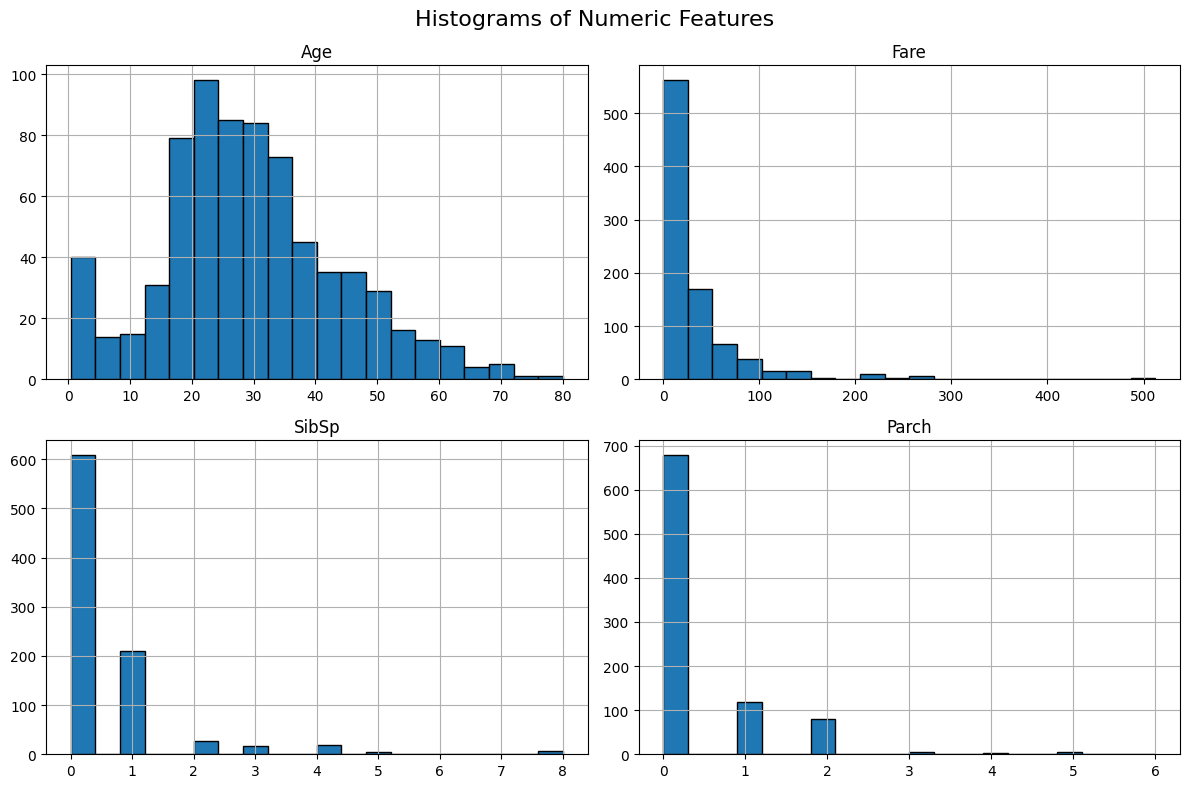

In [6]:
# Histograms show the DISTRIBUTION of values
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor='black')
# hist() → plots a histogram for each numeric column
# figsize → size of the overall plot grid
# bins=20 → divides data into 20 buckets
# edgecolor → adds black border to bars for clarity

plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.tight_layout()
# tight_layout() → prevents overlapping titles/labels
plt.show()

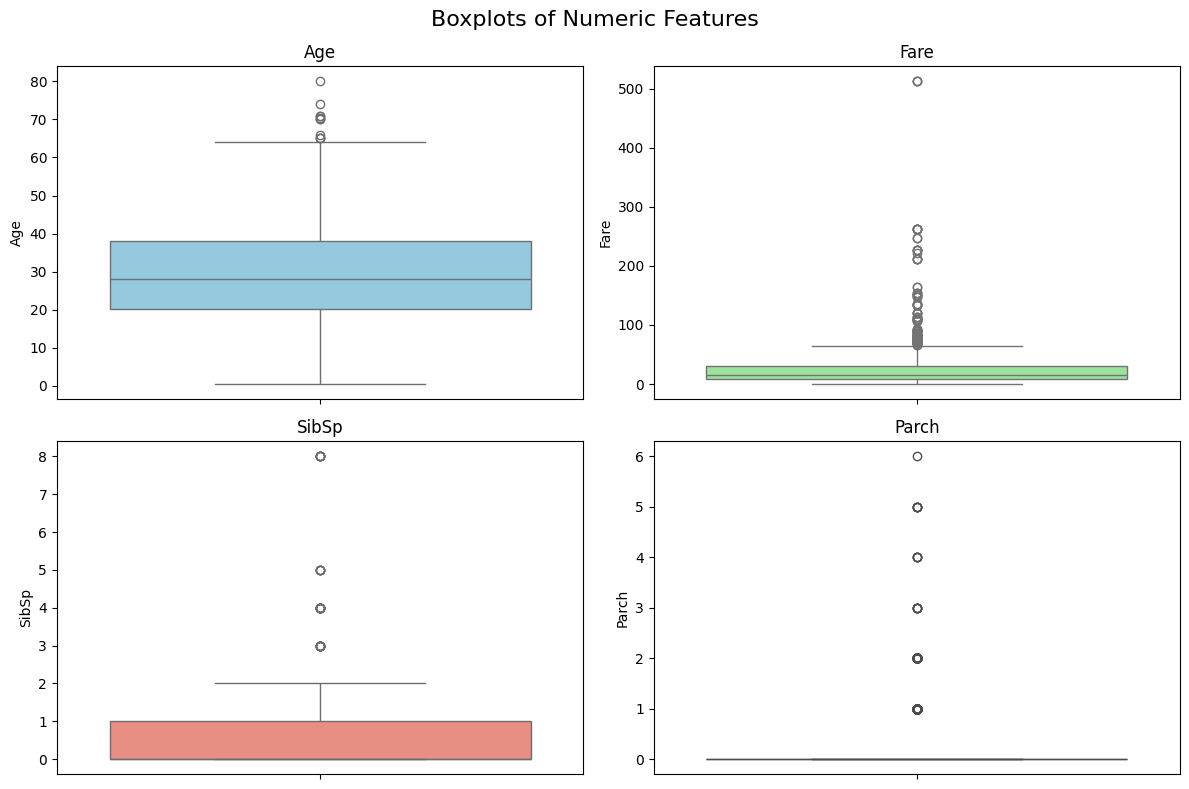

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# subplots(2,2) → creates a 2x2 grid of plots

sns.boxplot(y=df['Age'], ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age')

sns.boxplot(y=df['Fare'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Fare')

sns.boxplot(y=df['SibSp'], ax=axes[1,0], color='salmon')
axes[1,0].set_title('SibSp')

sns.boxplot(y=df['Parch'], ax=axes[1,1], color='gold')
axes[1,1].set_title('Parch')

plt.suptitle("Boxplots of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

          Survived    Pclass       Age     SibSp     Parch      Fare
Survived  1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307
Pclass   -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500
Age      -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067
SibSp    -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651
Parch     0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225
Fare      0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000


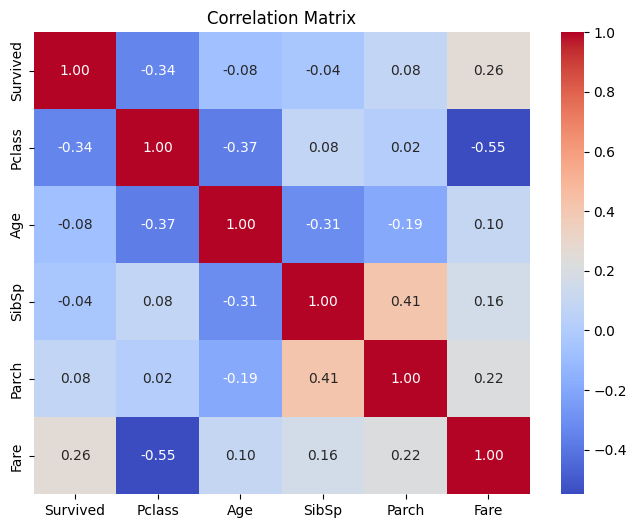

In [8]:
# Correlation only works on numeric columns
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]

corr_matrix = numeric_df.corr()
# corr() → calculates correlation between every pair of numeric columns
# Values range from -1 to +1
# +1 → perfect positive relationship
# -1 → perfect negative relationship
#  0 → no relationship

print(corr_matrix)

# Visualize with heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
# annot=True → shows correlation numbers on the heatmap
# cmap='coolwarm' → red=positive, blue=negative
# fmt='.2f' → rounds numbers to 2 decimal places

plt.title("Correlation Matrix")
plt.show()

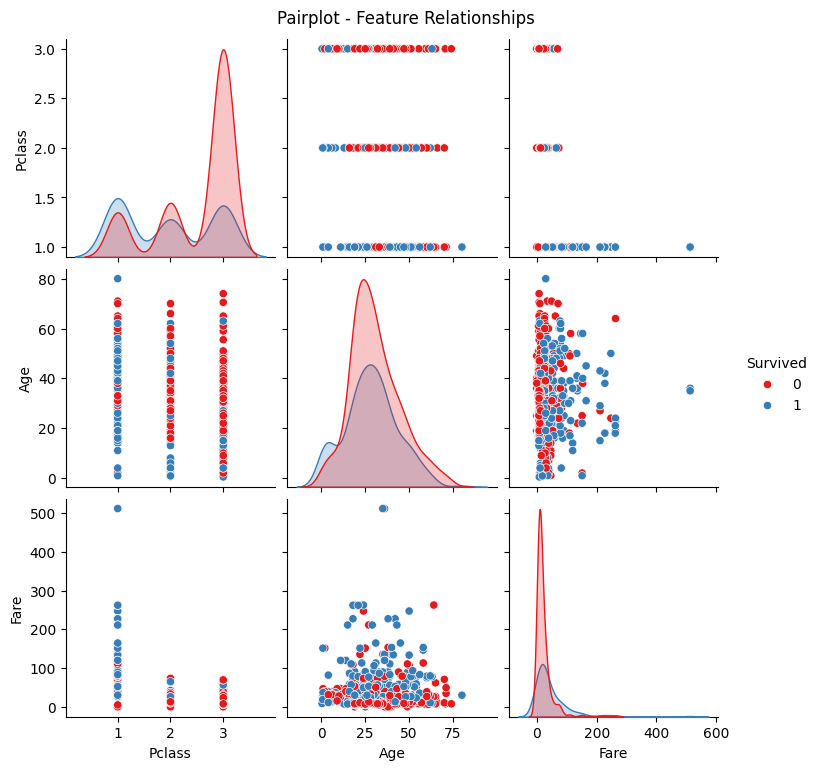

In [9]:
# Pairplot shows scatter plots between EVERY pair of numeric features
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']], hue='Survived', palette='Set1')
# hue='Survived' → colors points by survival (0=red, 1=blue)
# helps us SEE patterns, not just numbers

plt.suptitle("Pairplot - Feature Relationships", y=1.02)
plt.show()

In [10]:
# Survival rate by Sex
print("Survival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean())
# groupby() → groups data by Sex
# mean() of Survived → gives survival RATE (since 0/1 average = %)

# Survival rate by Pclass
print("\nSurvival Rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean())

# Survival rate by Embarked
print("\nSurvival Rate by Embarked:")
print(df.groupby('Embarked')['Survived'].mean())

Survival Rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival Rate by Embarked:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [11]:
# Check Pclass distribution by Embarked port
print("Pclass distribution by Embarked:")
print(pd.crosstab(df['Embarked'], df['Pclass']))
# crosstab() → creates a table showing counts of Pclass for each Embarked port

Pclass distribution by Embarked:
Pclass      1    2    3
Embarked               
C          85   17   66
Q           2    3   72
S         127  164  353


Survival Rate by Sex and Pclass:
Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


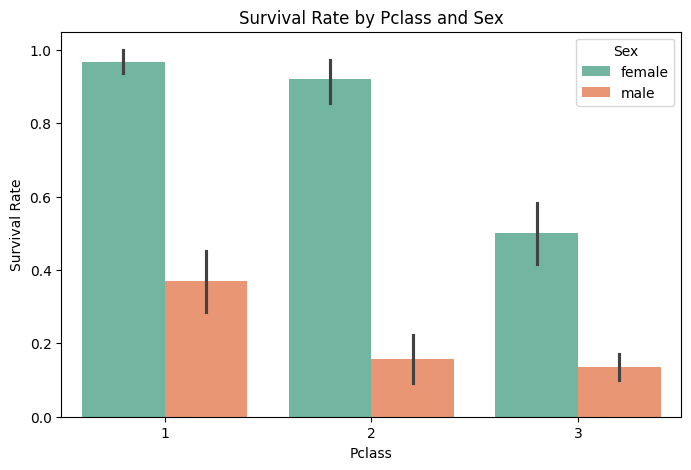

In [12]:
# Combined view: Sex + Pclass survival rate
print("Survival Rate by Sex and Pclass:")
print(df.groupby(['Pclass', 'Sex'])['Survived'].mean())

# Visualize this combination
plt.figure(figsize=(8, 5))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, palette='Set2')
plt.title("Survival Rate by Pclass and Sex")
plt.ylabel("Survival Rate")
plt.show()